In [1]:
from google.colab import files
uploaded = files.upload()   # select 2__Stock_Prices_Data_Set.csv

Saving 2) Stock Prices Data Set.csv to 2) Stock Prices Data Set.csv


In [2]:
# ── STEP 0: Upload dataset in Google Colab ───────────────────
# Run this cell FIRST before anything else:
#
# from google.colab import files
# uploaded = files.upload()   # select 2__Stock_Prices_Data_Set.csv


# ── Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)
from sklearn.calibration import calibration_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0



STEP 1: Load & Explore
Loaded file : 2) Stock Prices Data Set.csv
Shape      : (497472, 7)
Symbols    : 505 unique stocks
Date range : 2014-01-02 to 2017-12-29

First 5 rows:
  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391

Missing values:
symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


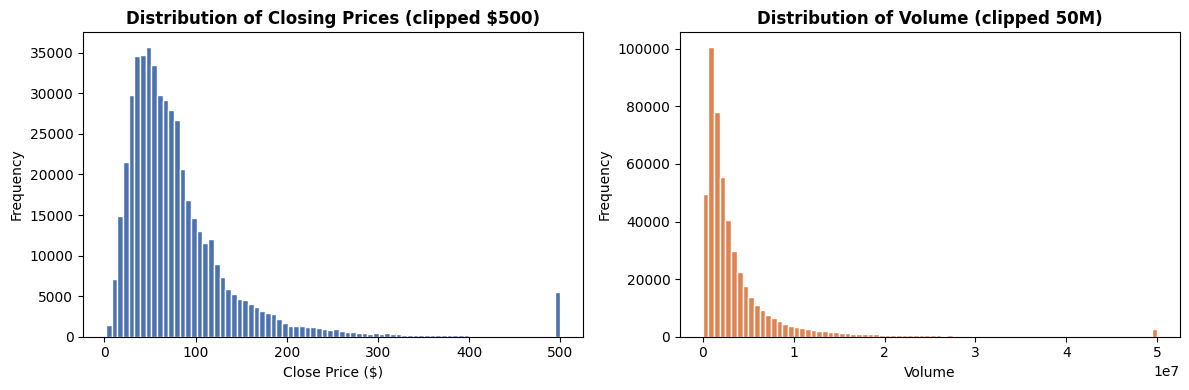

Saved: data_distribution.png


In [6]:
# ============================================================
# STEP 1: Load & Explore the Dataset
# ============================================================

print("\n" + "=" * 60)
print("STEP 1: Load & Explore")
print("=" * 60)

# ── Get the exact filename from the upload ───────────────────
import io
filename = list(uploaded.keys())[0]          # picks whatever file was uploaded
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Loaded file : {filename}")
print(f"Shape      : {df.shape}")
print(f"Symbols    : {df['symbol'].nunique()} unique stocks")
print(f"Date range : {df['date'].min()} to {df['date'].max()}")
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["close"].clip(upper=500), bins=80, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of Closing Prices (clipped $500)", fontweight="bold")
axes[0].set_xlabel("Close Price ($)")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["volume"].clip(upper=5e7), bins=80, color="#DD8452", edgecolor="white")
axes[1].set_title("Distribution of Volume (clipped 50M)", fontweight="bold")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("data_distribution.png", dpi=150)
plt.show()
print("Saved: data_distribution.png")

In [7]:
# ============================================================
# STEP 2: Feature Engineering
# ============================================================

print("\n" + "=" * 60)
print("STEP 2: Feature Engineering")
print("=" * 60)

df["date"] = pd.to_datetime(df["date"])
df.sort_values(["symbol", "date"], inplace=True)
df.reset_index(drop=True, inplace=True)
df.dropna(subset=["open", "high", "low", "close"], inplace=True)

grp = df.groupby("symbol")

# 1. Daily return
df["daily_return"]   = grp["close"].pct_change()

# 2. High-Low spread (volatility proxy)
df["hl_spread"]      = (df["high"] - df["low"]) / df["close"]

# 3. Open-Close spread
df["oc_spread"]      = (df["close"] - df["open"]) / df["open"]

# 4. 5-day and 20-day moving averages
df["ma5"]            = grp["close"].transform(lambda x: x.rolling(5).mean())
df["ma20"]           = grp["close"].transform(lambda x: x.rolling(20).mean())

# 5. MA ratio (trend signal: >1 means short-term up-trend)
df["ma5_ma20_ratio"] = df["ma5"] / df["ma20"]

# 6. 5-day rolling volatility of returns
df["volatility5"]    = grp["daily_return"].transform(lambda x: x.rolling(5).std())

# 7. Volume change
df["volume_change"]  = grp["volume"].pct_change()

# 8. RSI (14-day Relative Strength Index)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

df["rsi14"]     = grp["close"].transform(compute_rsi)

# 9. 5-day momentum
df["momentum5"] = grp["close"].transform(lambda x: x.pct_change(5))

# TARGET: 1 if next-day close > today's close, else 0
df["next_close"] = grp["close"].shift(-1)
df["target"]     = (df["next_close"] > df["close"]).astype(int)

FEATURES = [
    "daily_return", "hl_spread", "oc_spread",
    "ma5_ma20_ratio", "volatility5",
    "volume_change", "rsi14", "momentum5"
]

df.dropna(subset=FEATURES + ["target"], inplace=True)

print(f"Features : {FEATURES}")
print(f"Rows after feature engineering: {len(df):,}")
vc = df["target"].value_counts()
print(f"\nTarget distribution:")
print(f"  Up   (1): {vc[1]:>7,}  ({vc[1]/len(df)*100:.1f}%)")
print(f"  Down (0): {vc[0]:>7,}  ({vc[0]/len(df)*100:.1f}%)")



STEP 2: Feature Engineering
Features : ['daily_return', 'hl_spread', 'oc_spread', 'ma5_ma20_ratio', 'volatility5', 'volume_change', 'rsi14', 'momentum5']
Rows after feature engineering: 487,867

Target distribution:
  Up   (1): 253,426  (51.9%)
  Down (0): 234,441  (48.1%)


In [8]:
# ============================================================
# STEP 3: Chronological Train / Val / Test Split + Scale
# ============================================================

print("\n" + "=" * 60)
print("STEP 3: Train / Validation / Test Split")
print("=" * 60)

X = df[FEATURES].values
y = df["target"].values

n         = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],         y[:train_end]
X_val,   y_val   = X[train_end:val_end],  y[train_end:val_end]
X_test,  y_test  = X[val_end:],           y[val_end:]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]:>7,} samples")
print(f"Val   : {X_val.shape[0]:>7,} samples")
print(f"Test  : {X_test.shape[0]:>7,} samples")


STEP 3: Train / Validation / Test Split
Train : 341,506 samples
Val   :  73,180 samples
Test  :  73,181 samples


In [9]:
# ============================================================
# STEP 4: Design the Neural Network Architecture
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: Neural Network Architecture")
print("=" * 60)

def build_model(input_dim, learning_rate=0.001):
    """
    Feed-Forward Neural Network:
      Input (8)  ->  Dense(128, ReLU) + BatchNorm + Dropout(0.3)
                 ->  Dense(64,  ReLU) + BatchNorm + Dropout(0.3)
                 ->  Dense(32,  ReLU) + Dropout(0.2)
                 ->  Dense(1, Sigmoid)  [binary output]
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Hidden Layer 1
        layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden Layer 2
        layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Hidden Layer 3
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),

        # Output
        layers.Dense(1, activation="sigmoid")
    ], name="StockDirectionNN")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model

model = build_model(input_dim=len(FEATURES))
model.summary()

print("""
Architecture Diagram:
  Input(8)
    |
  Dense(128, ReLU) -> BatchNorm -> Dropout(0.3)
    |
  Dense(64, ReLU)  -> BatchNorm -> Dropout(0.3)
    |
  Dense(32, ReLU)  -> Dropout(0.2)
    |
  Dense(1, Sigmoid)  ->  P(price goes UP tomorrow)
""")



STEP 4: Neural Network Architecture


Model: "StockDirectionNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)


Architecture Diagram:
  Input(8)
    |
  Dense(128, ReLU) -> BatchNorm -> Dropout(0.3)
    |
  Dense(64, ReLU)  -> BatchNorm -> Dropout(0.3)
    |
  Dense(32, ReLU)  -> Dropout(0.2)
    |
  Dense(1, Sigmoid)  ->  P(price goes UP tomorrow)



In [10]:
# ============================================================
# STEP 5: Train the Model (Backpropagation)
# ============================================================

print("\n" + "=" * 60)
print("STEP 5: Training with Backpropagation")
print("=" * 60)

early_stop = callbacks.EarlyStopping(
    monitor="val_auc", mode="max",
    patience=8, restore_best_weights=True, verbose=1
)
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5,
    patience=4, min_lr=1e-6, verbose=1
)
model_ckpt = callbacks.ModelCheckpoint(
    "best_model.keras", monitor="val_auc",
    mode="max", save_best_only=True, verbose=0
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=512,
    callbacks=[early_stop, lr_scheduler, model_ckpt],
    verbose=1
)

print(f"\nTraining completed after {len(history.history['loss'])} epochs")


STEP 5: Training with Backpropagation
Epoch 1/60
668/668 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.5101 - auc: 0.5067 - loss: 0.7177 - precision: 0.5231 - recall: 0.6417 - val_accuracy: 0.5249 - val_auc: 0.5245 - val_loss: 0.7006 - val_precision: 0.5273 - val_recall: 0.8195 - learning_rate: 0.0010
Epoch 2/60
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5183 - auc: 0.5162 - loss: 0.7010 - precision: 0.5248 - recall: 0.7658 - val_accuracy: 0.5253 - val_auc: 0.5299 - val_loss: 0.6987 - val_precision: 0.5275 - val_recall: 0.8206 - learning_rate: 0.0010
Epoch 3/60
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5218 - auc: 0.5228 - loss: 0.6982 - precision: 0.5262 - recall: 0.7965 - val_accuracy: 0.5283 - val_auc: 0.5334 - val_loss: 0.6964 - val_precision: 0.5281 - val_recall: 0.8587 - learning_rate: 0.0010
Epoch 4/60
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5240 - auc: 0.5259 - loss: 0.6961 - precision: 0.5275 - recall: 0.8003 - val_accuracy: 0.5282 -


STEP 6: Training & Validation Loss / Accuracy Curves


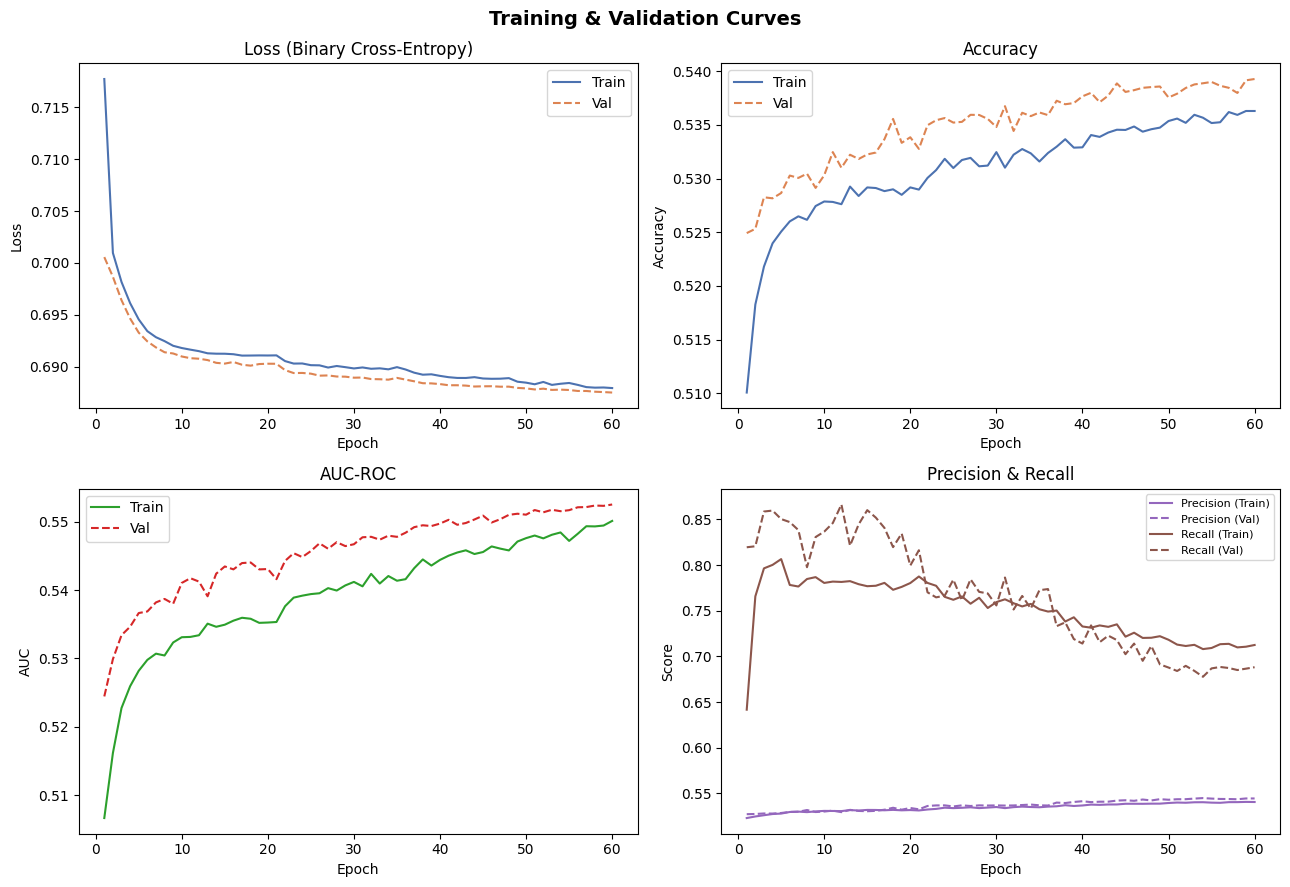

Saved: training_curves.png


In [11]:
# ============================================================
# STEP 6: Visualize Training / Validation Curves
# ============================================================

print("\n" + "=" * 60)
print("STEP 6: Training & Validation Loss / Accuracy Curves")
print("=" * 60)

hist = history.history
ep   = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Training & Validation Curves", fontsize=14, fontweight="bold")

# Loss
axes[0, 0].plot(ep, hist["loss"],     color="#4C72B0", label="Train")
axes[0, 0].plot(ep, hist["val_loss"], color="#DD8452", linestyle="--", label="Val")
axes[0, 0].set_title("Loss (Binary Cross-Entropy)")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# Accuracy
axes[0, 1].plot(ep, hist["accuracy"],     color="#4C72B0", label="Train")
axes[0, 1].plot(ep, hist["val_accuracy"], color="#DD8452", linestyle="--", label="Val")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

# AUC
axes[1, 0].plot(ep, hist["auc"],     color="#2CA02C", label="Train")
axes[1, 0].plot(ep, hist["val_auc"], color="#D62728", linestyle="--", label="Val")
axes[1, 0].set_title("AUC-ROC")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("AUC")
axes[1, 0].legend()

# Precision & Recall
axes[1, 1].plot(ep, hist["precision"],     color="#9467BD", label="Precision (Train)")
axes[1, 1].plot(ep, hist["val_precision"], color="#9467BD", linestyle="--", label="Precision (Val)")
axes[1, 1].plot(ep, hist["recall"],        color="#8C564B", label="Recall (Train)")
axes[1, 1].plot(ep, hist["val_recall"],    color="#8C564B", linestyle="--", label="Recall (Val)")
axes[1, 1].set_title("Precision & Recall")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Score")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")



STEP 7: Test Set Evaluation

Test Metrics (from model.evaluate):
  Loss        : 0.6880
  Accuracy    : 0.5375
  Precision   : 0.5443
  Recall      : 0.6818
  AUC         : 0.5495

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.52      0.38      0.44     35105
      Up (1)       0.54      0.68      0.61     38076

    accuracy                           0.54     73181
   macro avg       0.53      0.53      0.52     73181
weighted avg       0.53      0.54      0.53     73181



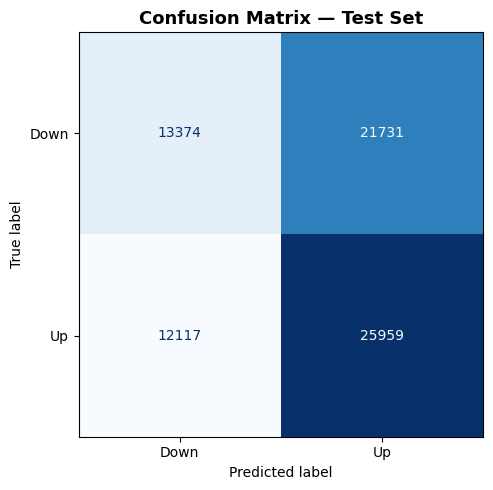

Saved: confusion_matrix.png


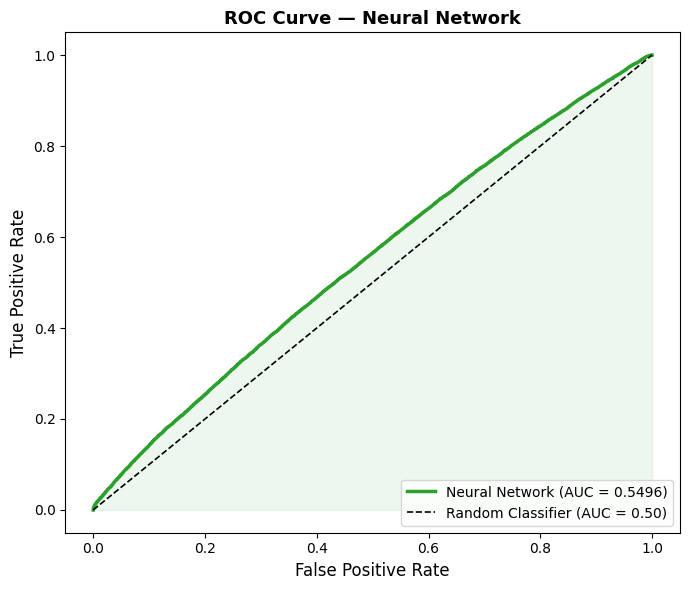

Saved: roc_curve.png


In [12]:
# ============================================================
# STEP 7: Evaluate on Test Set
# ============================================================

print("\n" + "=" * 60)
print("STEP 7: Test Set Evaluation")
print("=" * 60)

model = keras.models.load_model("best_model.keras")

test_results  = model.evaluate(X_test, y_test, verbose=0)
metric_names  = ["Loss", "Accuracy", "Precision", "Recall", "AUC"]
print("\nTest Metrics (from model.evaluate):")
for name, val in zip(metric_names, test_results):
    print(f"  {name:12s}: {val:.4f}")

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Down (0)", "Up (1)"]))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Down", "Up"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Confusion Matrix — Test Set", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#2CA02C", lw=2.5, label=f"Neural Network (AUC = {roc_auc_val:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#2CA02C")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Neural Network", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print("Saved: roc_curve.png")



STEP 8: Architecture Comparison
  Training: Shallow (1x64) ...
    AUC=0.5392  F1=0.6473
  Training: Wide   (1x256) ...
    AUC=0.5383  F1=0.6502
  Training: Deep   (3 hidden) ...
    AUC=0.5429  F1=0.6434

Architecture Comparison:
                   Accuracy  Precision  Recall      F1     AUC
Shallow (1x64)       0.5318     0.5323  0.8258  0.6473  0.5392
Wide   (1x256)       0.5310     0.5313  0.8376  0.6502  0.5383
Deep   (3 hidden)    0.5342     0.5347  0.8078  0.6434  0.5429


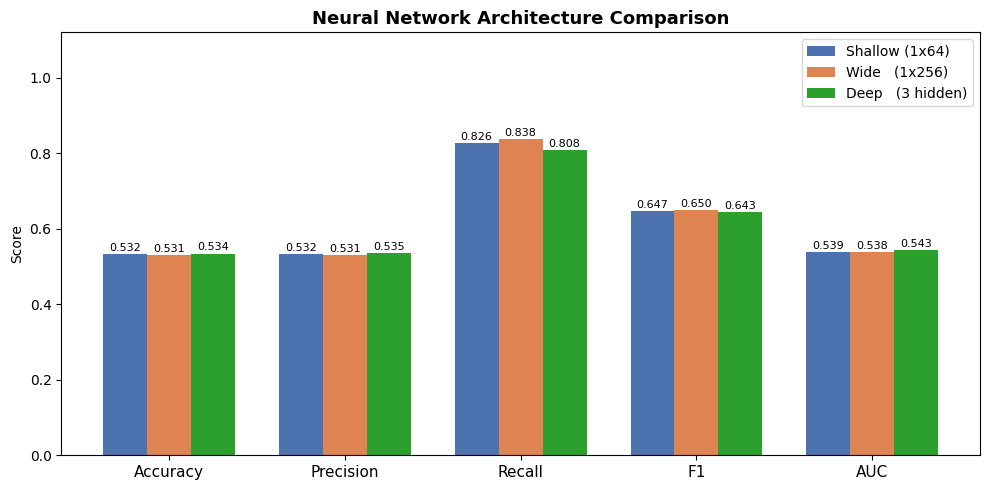

Saved: architecture_comparison.png


In [13]:
# ============================================================
# STEP 8: Architecture Comparison (Shallow vs Wide vs Deep)
# ============================================================

print("\n" + "=" * 60)
print("STEP 8: Architecture Comparison")
print("=" * 60)

def build_shallow(d):
    m = keras.Sequential([
        layers.Input(shape=(d,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid")
    ], name="Shallow")
    m.compile(optimizer="adam", loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return m

def build_wide(d):
    m = keras.Sequential([
        layers.Input(shape=(d,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid")
    ], name="Wide")
    m.compile(optimizer="adam", loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return m

arch_results = {}
for name, builder in [("Shallow (1x64)",  build_shallow),
                       ("Wide   (1x256)",  build_wide),
                       ("Deep   (3 hidden)", build_model)]:
    print(f"  Training: {name} ...")
    m  = builder(len(FEATURES))
    es = callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                 patience=5, restore_best_weights=True)
    m.fit(X_train, y_train, validation_data=(X_val, y_val),
          epochs=30, batch_size=512, callbacks=[es], verbose=0)
    probs = m.predict(X_test, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    arch_results[name] = {
        "Accuracy" : accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall"   : recall_score(y_test, preds),
        "F1"       : f1_score(y_test, preds),
        "AUC"      : roc_auc_score(y_test, probs),
    }
    print(f"    AUC={arch_results[name]['AUC']:.4f}  F1={arch_results[name]['F1']:.4f}")

arch_df = pd.DataFrame(arch_results).T
print("\nArchitecture Comparison:")
print(arch_df.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(arch_df.columns))
width  = 0.25
colors = ["#4C72B0", "#DD8452", "#2CA02C"]
for i, (aname, row) in enumerate(arch_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=aname, color=colors[i])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels(arch_df.columns, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Neural Network Architecture Comparison", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("architecture_comparison.png", dpi=150)
plt.show()
print("Saved: architecture_comparison.png")


STEP 9: Prediction Probability Analysis


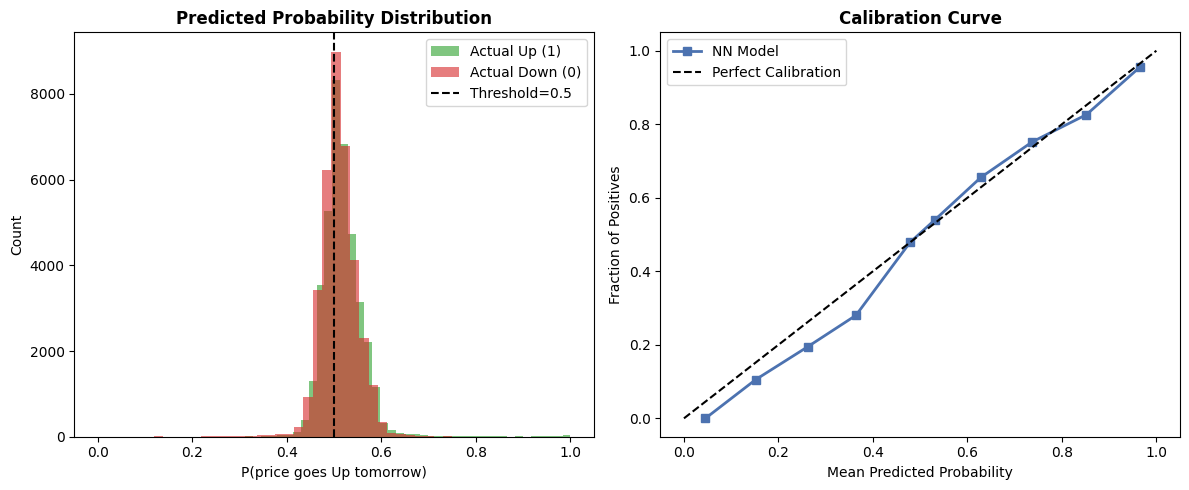

Saved: prediction_analysis.png


In [14]:
# ============================================================
# STEP 9: Prediction Probability Analysis + Calibration
# ============================================================

print("\n" + "=" * 60)
print("STEP 9: Prediction Probability Analysis")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Probability histogram split by actual class
axes[0].hist(y_prob[y_test == 1], bins=50, alpha=0.6,
             color="#2CA02C", label="Actual Up (1)")
axes[0].hist(y_prob[y_test == 0], bins=50, alpha=0.6,
             color="#D62728", label="Actual Down (0)")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold=0.5")
axes[0].set_xlabel("P(price goes Up tomorrow)")
axes[0].set_ylabel("Count")
axes[0].set_title("Predicted Probability Distribution", fontweight="bold")
axes[0].legend()

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
axes[1].plot(prob_pred, prob_true, "s-", color="#4C72B0", lw=2, label="NN Model")
axes[1].plot([0, 1], [0, 1], "k--", label="Perfect Calibration")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Fraction of Positives")
axes[1].set_title("Calibration Curve", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("prediction_analysis.png", dpi=150)
plt.show()
print("Saved: prediction_analysis.png")


In [15]:
# ============================================================
# STEP 10: Final Summary
# ============================================================

print("\n" + "=" * 60)
print("STEP 10: Final Results Summary")
print("=" * 60)

final = {
    "Accuracy" : accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall"   : recall_score(y_test, y_pred),
    "F1-Score" : f1_score(y_test, y_pred),
    "AUC-ROC"  : roc_auc_score(y_test, y_prob),
}
print("\nDeep NN (3 Hidden Layers) — Test Set Performance:")
for k, v in final.items():
    print(f"  {k:12s}: {v:.4f}")

print("""
SUMMARY
-------
Dataset     : S&P 500 Stock Prices 2014-2017 (497K rows, 505 stocks)
Target      : Binary: next-day close > today's close? (Up=1, Down=0)
Features    : 8 engineered technical indicators
              daily_return, hl_spread, oc_spread, ma5_ma20_ratio,
              volatility5, volume_change, rsi14, momentum5
Split       : Chronological 70/15/15 (avoids data leakage)
Scaling     : StandardScaler (fit on train only)

Best Network Architecture:
  Input(8) -> Dense(128,ReLU)+BN+Drop(0.3)
           -> Dense(64, ReLU)+BN+Drop(0.3)
           -> Dense(32, ReLU)+Drop(0.2)
           -> Dense(1, Sigmoid)

Training:
  Optimizer  : Adam (lr=0.001)
  Loss       : Binary Cross-Entropy
  Regularization: L2 + BatchNorm + Dropout
  Callbacks  : EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

Saved Plots:
  data_distribution.png
  training_curves.png        (loss, accuracy, AUC, precision/recall)
  confusion_matrix.png
  roc_curve.png
  architecture_comparison.png
  prediction_analysis.png
""")



STEP 10: Final Results Summary

Deep NN (3 Hidden Layers) — Test Set Performance:
  Accuracy    : 0.5375
  Precision   : 0.5443
  Recall      : 0.6818
  F1-Score    : 0.6053
  AUC-ROC     : 0.5496

SUMMARY
-------
Dataset     : S&P 500 Stock Prices 2014-2017 (497K rows, 505 stocks)
Target      : Binary: next-day close > today's close? (Up=1, Down=0)
Features    : 8 engineered technical indicators
              daily_return, hl_spread, oc_spread, ma5_ma20_ratio,
              volatility5, volume_change, rsi14, momentum5
Split       : Chronological 70/15/15 (avoids data leakage)
Scaling     : StandardScaler (fit on train only)
 
Best Network Architecture:
  Input(8) -> Dense(128,ReLU)+BN+Drop(0.3)
           -> Dense(64, ReLU)+BN+Drop(0.3)
           -> Dense(32, ReLU)+Drop(0.2)
           -> Dense(1, Sigmoid)
 
Training:
  Optimizer  : Adam (lr=0.001)
  Loss       : Binary Cross-Entropy
  Regularization: L2 + BatchNorm + Dropout
  Callbacks  : EarlyStopping, ReduceLROnPlateau, ModelChe